# Compare models on MIMIC-III mortality (COPER vs transformer baseline)

Single codebase: `code/COPER`. Training entry point: `utils/run_exp.py` (choose architecture with `--model-type`).

## Shared front end (all runs in this notebook)

- Optional linear embedding of vitals, then (with `--cont-in`) a **Neural ODE** on the irregular timeline so the model sees a regular grid `(batch, seq_len, features)`.

## What differs: COPER / Perceiver vs `TRANSFORMER`

In this repo, **`COPER` and `PERCEIVER` both instantiate the same class** `COPER` in `src_coper/coper_model.py`. The alternative baseline is **`TRANSFORMER`** in `src_coper/transformer_model.py`.

| | **COPER** (`--model-type COPER`) | **Transformer baseline** (`--model-type TRANSFORMER`) |
|---|--------------------------------|--------------------------------------------------------|
| Bottleneck | Fixed learned **latent queries** `(num_latents, latent_dim)`; **cross-attention** latents→sequence, then **self-attention among latents** only | **No** latent bottleneck; first block is **self-attention over time** (Q,K,V from the sequence) |
| Cost scaling | Dominated by **num_latents × T** in cross-attention (often `num_latents ≪ T`) | Dominated by **T × T** per layer on the ODE grid |
| **`--second-node`** | Optional **second Neural ODE on the Perceiver latent grid** (2-NODE variant) | Optional **second Neural ODE on the sequence** after self-attention (same flag) |

**1-NODE vs 2-NODE**: toggle with `--second-node` for **both** COPER and TRANSFORMER. `run_exp.py` adds checkpoint suffix `_N2` for 2-NODE (e.g. `COPER-mimic-..._S1_N2.ckpt`, `TRANSFORMER-mimic-..._S1_N2.ckpt`).

Set `INCLUDE_TRANSFORMER_BASELINE` in the next cell to `False` if you only want the two COPER variants (faster).

## Outputs

Training writes under `--results-dir` (here: `results/runs/YYYY-MM-DD_mimic_compare/`) into `checkpoints/`, `logs/`, `predictions/` (`Predictions_*.npz`), and `traces/`. Exported bundles go to `models/` in that same run folder via `utils/export_coper_checkpoint.py` (pass `--model-type` for the transformer).

After export, the notebook also updates `results/latest_mimic_compare_models_dir.txt` automatically so downstream notebooks (notably `coper_to_states.ipynb`) can load the latest model directory without manual path edits.

For a **fair comparison** with the classical baselines (logistic / RF / LSTM) in this notebook, **`DROPS = [0.0]`**: no input-time random time-drop (`--drop` omitted), same full 48-step tensors as the pickle. Export names then use `drop0` (e.g. `coper_1node_drop0_s1_e1.pt`). **`NITERS_LIST`** must match **`NITERS_TO_VIS`** in `display_embeddings.ipynb` when you reuse bundles there.

**Note:** If `NITERS_LIST` has **multiple** epoch counts, training runs them in order; `predictions/Predictions_*.npz` are overwritten so filenames match the **last** completed `niters` in the list (unless you change `--results-dir` between runs). Classical baselines (logistic / RF / LSTM) are saved under `results/demo_outputs/coper_vs_transformer_mortality/models/` as `.joblib` / `.pt` plus `mimic3_baselines_manifest.json` in `tables/`.


In [1]:
from __future__ import annotations

import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

BENCH = Path('/home/charlesv/Desktop/StatisitcalGenetics/code/COPER').resolve()
if str(BENCH) not in sys.path:
    sys.path.insert(0, str(BENCH))

from utils.benchmark_utils import (
    patch_paths_json,
    restore_paths_json,
    run_one,
)

In [2]:
# ---- Paths and benchmark config ----
ROOT = Path('/home/charlesv/Desktop/StatisitcalGenetics')
REPO = ROOT / 'code' / 'COPER'
assert REPO.is_dir(), f'Missing repo: {REPO}'

# Training outputs go under a dated session: results/runs/YYYY-MM-DD_mimic_compare/{checkpoints,logs,predictions,models,traces,...}
BENCH = ROOT / 'code' / 'COPER'
from utils.results_layout import dated_session_dir, notebook_demo_dir

RESULTS_ROOT = dated_session_dir(BENCH, 'mimic_compare')
MODELS_DIR = RESULTS_ROOT / 'models'

# Optional full-sequence transformer baseline (O(T²) attention per layer — slower / more memory).
INCLUDE_TRANSFORMER_BASELINE = True

# (arch_id, human label, extra CLI tokens after BASE_SHARED_ARGS; each row sets --model-type)
ARCHITECTURES_CORE = [
    ('coper_1node', '1-NODE (ODE → Perceiver)', ['--model-type', 'COPER']),
    ('coper_2node', '2-NODE (ODE → Perceiver → ODE on latents)', ['--model-type', 'COPER', '--second-node']),
]
ARCHITECTURES_XFM = [
    (
        'transformer_baseline',
        'TRANSFORMER (ODE → T×T self-attention)',
        ['--model-type', 'TRANSFORMER'],
    ),
    (
        'transformer_2node',
        'TRANSFORMER 2-NODE (ODE → T×T self-attention → ODE on sequence)',
        ['--model-type', 'TRANSFORMER', '--second-node'],
    ),
]
ARCHITECTURES = ARCHITECTURES_CORE + (ARCHITECTURES_XFM if INCLUDE_TRANSFORMER_BASELINE else [])

FOLD = -1  # must match utils/run_exp default / your training setup (checkpoint name uses this)

from data_mngmt import mortality_pickle_path

MORTALITY_PICKLE = mortality_pickle_path()
assert MORTALITY_PICKLE.is_file(), f'Missing dataset file: {MORTALITY_PICKLE}'

# Smoke-test defaults. Increase for full benchmark.
SEEDS = [1]
# Input-time drop disabled (0) so deep models see full sequences like sklearn/LSTM baselines.
# ODE/attention/ff dropout in BASE_SHARED_ARGS still applies as regularization.
DROPS = [0.0]
# Train+export once per entry (each run uses --niters below). Keep in sync with `NITERS_TO_VIS` in `display_embeddings.ipynb`.
NITERS_LIST = [
    1,
    3,
    10
]
BATCH_SIZE = 64
PATIENCE = 10

# Shared hyperparameters (same as run_irregular_mimic.sh); --model-type is per-architecture above; --niters comes from NITERS_LIST in the run loop.
BASE_SHARED_ARGS = [
    '--dataset', 'mimic',
    '--cont-in',
    '--self-per-cross-attn', '1',
    '--latent-heads', '2',
    '--cross-heads', '1',
    '--cross-dim-head', '128',
    '--latent-dim-head', '128',
    '--latent-dim', '64',
    '--units', '128',
    '--ode-dropout', '0.5',
    '--att-dropout', '0.5',
    '--ff-dropout', '0.5',
    '--num-latents', '48',
    '--batch-size', str(BATCH_SIZE),
    '--patience', str(PATIENCE),
    '--results-dir', str(RESULTS_ROOT.resolve()),
]

print('Repo:', REPO)
print('Results root:', RESULTS_ROOT)
print('Include transformer baseline:', INCLUDE_TRANSFORMER_BASELINE)
print('NITERS_LIST:', NITERS_LIST)
print('Architectures:', [a[0] for a in ARCHITECTURES])
print('Dataset:', MORTALITY_PICKLE)


Repo: /home/charlesv/Desktop/StatisitcalGenetics/code/COPER
Results root: /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/results/runs/2026-04-10_mimic_compare
Include transformer baseline: True
NITERS_LIST: [1, 3, 10]
Architectures: ['coper_1node', 'coper_2node', 'transformer_baseline', 'transformer_2node']
Dataset: /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/data_mngmt/generated/mortality_coper_sepsis-60m-h48ihm.data


In [3]:
# ---- Run benchmark grid (architectures × NITERS_LIST) ----
rows = []

backup = patch_paths_json(REPO, MORTALITY_PICKLE)
try:
    for niters in NITERS_LIST:
        shared_args = BASE_SHARED_ARGS + ['--niters', str(niters)]
        for arch_id, arch_label, extra_args in ARCHITECTURES:
            for seed in SEEDS:
                for drop in DROPS:
                    print(
                        f'Running {arch_id} [{arch_label}] | niters={niters} | seed={seed} | drop={drop}'
                    )
                    r = run_one(
                        arch_id=arch_id,
                        arch_label=arch_label,
                        extra_args=extra_args,
                        seed=seed,
                        drop=drop,
                        shared_args=shared_args,
                        repo=REPO,
                        results_root=RESULTS_ROOT,
                        fold=FOLD,
                        python_executable=sys.executable,
                    )
                    rows.append(r)
                    print(
                        f"  rc={r['return_code']} "
                        f"Test-OG AUROC={r['test_og_auroc']:.4f} "
                        f"Test-G AUROC={r['test_g_auroc']:.4f} "
                        f"ckpt_exists={r['ckpt_exists']}"
                    )
                    if r['return_code'] != 0:
                        print('  ---- error tail ----')
                        print(r['raw_tail'])
finally:
    restore_paths_json(REPO, backup)

results_df = pd.DataFrame(rows)

expected = {(a[0], n) for a in ARCHITECTURES for n in NITERS_LIST}
seen = set(zip(results_df['arch_id'], results_df['niters']))
missing = expected - seen
assert not missing, f'Missing runs: {sorted(missing)}'

results_df

Running coper_1node [1-NODE (ODE → Perceiver)] | niters=1 | seed=1 | drop=0.0
  rc=0 Test-OG AUROC=0.6223 Test-G AUROC=0.6234 ckpt_exists=True
Running coper_2node [2-NODE (ODE → Perceiver → ODE on latents)] | niters=1 | seed=1 | drop=0.0
  rc=0 Test-OG AUROC=0.5959 Test-G AUROC=0.5977 ckpt_exists=True
Running transformer_baseline [TRANSFORMER (ODE → T×T self-attention)] | niters=1 | seed=1 | drop=0.0
  rc=0 Test-OG AUROC=0.6465 Test-G AUROC=0.6480 ckpt_exists=True
Running transformer_2node [TRANSFORMER 2-NODE (ODE → T×T self-attention → ODE on sequence)] | niters=1 | seed=1 | drop=0.0
  rc=0 Test-OG AUROC=0.6139 Test-G AUROC=0.6101 ckpt_exists=True
Running coper_1node [1-NODE (ODE → Perceiver)] | niters=3 | seed=1 | drop=0.0
  rc=0 Test-OG AUROC=0.6725 Test-G AUROC=0.6704 ckpt_exists=True
Running coper_2node [2-NODE (ODE → Perceiver → ODE on latents)] | niters=3 | seed=1 | drop=0.0
  rc=0 Test-OG AUROC=0.6533 Test-G AUROC=0.6596 ckpt_exists=True
Running transformer_baseline [TRANSFORME

,arch_id,architecture,model_type,niters,second_node,repo_dir,seed,drop,return_code,runtime_sec,...,test_g_auroc,test_g_auprc,test_g_accuracy,val_auroc,val_auprc,val_accuracy,train_auroc,train_auprc,train_accuracy,raw_tail
0,coper_1node,1-NODE (ODE → Perceiver),COPER,1,False,/home/charlesv/Desktop/StatisitcalGenetics/cod...,1,0.0,0,58.305097,...,0.6234,0.3317,0.6359,0.6625,0.4632,0.6687,0.6527,0.3945,0.6126,(diffeq_solver): DiffeqSolver(\n ...
1,coper_2node,2-NODE (ODE → Perceiver → ODE on latents),COPER,1,True,/home/charlesv/Desktop/StatisitcalGenetics/cod...,1,0.0,0,107.223106,...,0.5977,0.3306,0.5421,0.6105,0.4032,0.5794,0.6150,0.3647,0.5754,(cross_attn): Transformer(\n (mha): M...
2,transformer_baseline,TRANSFORMER (ODE → T×T self-attention),TRANSFORMER,1,False,/home/charlesv/Desktop/StatisitcalGenetics/cod...,1,0.0,0,57.200838,...,0.6480,0.3805,0.5615,0.6655,0.4864,0.5809,0.6498,0.4120,0.6225,(diffeq_solver): DiffeqSolver(\n ...
3,transformer_2node,TRANSFORMER 2-NODE (ODE → T×T self-attention →...,TRANSFORMER,1,True,/home/charlesv/Desktop/StatisitcalGenetics/cod...,1,0.0,0,108.206673,...,0.6101,0.3294,0.6003,0.6505,0.4420,0.6194,0.6177,0.3689,0.5818,(cross_attn): Transformer(\n (mha): M...
4,coper_1node,1-NODE (ODE → Perceiver),COPER,3,False,/home/charlesv/Desktop/StatisitcalGenetics/cod...,1,0.0,0,110.878822,...,0.6704,0.3914,0.6230,0.7039,0.5007,0.6410,0.7057,0.4805,0.6488,"(w_q): Linear(in_features=64, out_feat..."
5,coper_2node,2-NODE (ODE → Perceiver → ODE on latents),COPER,3,True,/home/charlesv/Desktop/StatisitcalGenetics/cod...,1,0.0,0,214.434605,...,0.6596,0.3873,0.6699,0.6829,0.4892,0.6256,0.6899,0.4637,0.6102,"(0): Linear(in_features=64, out_feat..."
6,transformer_baseline,TRANSFORMER (ODE → T×T self-attention),TRANSFORMER,3,False,/home/charlesv/Desktop/StatisitcalGenetics/cod...,1,0.0,0,111.416260,...,0.6922,0.4302,0.6812,0.7128,0.5337,0.6872,0.7209,0.5110,0.6460,"(w_q): Linear(in_features=32, out_feat..."
7,transformer_2node,TRANSFORMER 2-NODE (ODE → T×T self-attention →...,TRANSFORMER,3,True,/home/charlesv/Desktop/StatisitcalGenetics/cod...,1,0.0,0,216.669692,...,0.6683,0.4187,0.6359,0.7006,0.5151,0.6487,0.6989,0.4775,0.6354,"(0): Linear(in_features=32, out_feat..."
8,coper_1node,1-NODE (ODE → Perceiver),COPER,10,False,/home/charlesv/Desktop/StatisitcalGenetics/cod...,1,0.0,0,305.911827,...,0.7183,0.4639,0.6845,0.7263,0.5524,0.6626,0.7497,0.5381,0.7081,Val Epoch: 0005 | Val Loss 0.568263\nNumber of...
9,coper_2node,2-NODE (ODE → Perceiver → ODE on latents),COPER,10,True,/home/charlesv/Desktop/StatisitcalGenetics/cod...,1,0.0,0,582.444301,...,0.7193,0.4722,0.7006,0.7300,0.5525,0.6749,0.7471,0.5392,0.6818,Val Epoch: 0005 | Val Loss 0.582367\nNumber of...


## Classical baselines + LSTM (same mortality pickle)

The deep runs above report **test** AUROC/AUPRC from `utils/run_exp.py`. For **train / validation** metrics that are easy to read, each successful deep run now also logs **Train** and last-epoch **Val** lines (including **Accuracy** at the Youden threshold, same as `src_coper/metrics.py`).

The cell below fits **flattened logistic regression** (L2 and L1 / “lasso” penalty), **random forest**, and a small **PyTorch LSTM** on the **same** `X_train, y_train, X_val, y_val, X_test, y_test` tensors from `MORTALITY_PICKLE`, prints a comparison table, and **saves** fitted models to `results/demo_outputs/coper_vs_transformer_mortality/models/` (`mortality_logistic_l2.joblib`, `mortality_logistic_l1.joblib`, `mortality_random_forest.joblib`, `mortality_lstm.pt` with `state_dict` + hyperparameters, plus `baselines_manifest.json`).


In [4]:
# ---- Classical baselines + LSTM vs deep runs (accuracy focus) ----
import json
import pickle

import joblib
import torch

from utils.lstm import fit_lstm_mortality
from utils.random_forest import fit_random_forest_mortality
from utils.regression import fit_logistic_mortality

BASELINES_MODELS_DIR = notebook_demo_dir("models", "coper_vs_transformer_mortality", BENCH)
BASELINES_MODELS_DIR.mkdir(parents=True, exist_ok=True)

assert MORTALITY_PICKLE.is_file(), MORTALITY_PICKLE
with open(MORTALITY_PICKLE, "rb") as f:
    _det, X_train, y_train, X_val, y_val, X_test, y_test, _ = pickle.load(f)

baselines_manifest = {
    "mortality_pickle": str(MORTALITY_PICKLE),
    "models_dir": str(BASELINES_MODELS_DIR.resolve()),
    "artifacts": [],
}


def _metrics_only(row: dict) -> dict:
    keys = (
        "model",
        "penalty",
        "C",
        "n_estimators",
        "max_depth",
        "input_dim",
        "hidden_dim",
        "num_layers",
        "bidirectional",
        "dropout",
        "epochs_trained",
        "train_accuracy",
        "val_accuracy",
        "test_accuracy",
        "train_auroc",
        "val_auroc",
        "test_auroc",
    )
    return {k: row[k] for k in keys if k in row and k in row}


baseline_rows = []

r = {"family": "logistic_l2", **fit_logistic_mortality(X_train, y_train, X_val, y_val, X_test, y_test, penalty="l2")}
est = r.pop("estimator")
path = BASELINES_MODELS_DIR / "mortality_logistic_l2.joblib"
joblib.dump(est, path)
baselines_manifest["artifacts"].append({"family": "logistic_l2", "path": str(path), **_metrics_only(r)})
baseline_rows.append(r)

r = {"family": "logistic_l1", **fit_logistic_mortality(X_train, y_train, X_val, y_val, X_test, y_test, penalty="l1")}
est = r.pop("estimator")
path = BASELINES_MODELS_DIR / "mortality_logistic_l1.joblib"
joblib.dump(est, path)
baselines_manifest["artifacts"].append({"family": "logistic_l1", "path": str(path), **_metrics_only(r)})
baseline_rows.append(r)

r = {"family": "random_forest", **fit_random_forest_mortality(X_train, y_train, X_val, y_val, X_test, y_test)}
est = r.pop("estimator")
path = BASELINES_MODELS_DIR / "mortality_random_forest.joblib"
joblib.dump(est, path)
baselines_manifest["artifacts"].append({"family": "random_forest", "path": str(path), **_metrics_only(r)})
baseline_rows.append(r)

r = {"family": "lstm", **fit_lstm_mortality(X_train, y_train, X_val, y_val, X_test, y_test, max_epochs=40, patience=7)}
lstm_mod = r.pop("estimator")
path = BASELINES_MODELS_DIR / "mortality_lstm.pt"
payload = {
    "state_dict": lstm_mod.state_dict(),
    "input_dim": int(r.get("input_dim", X_train.shape[-1])),
    "hidden_dim": int(r["hidden_dim"]),
    "num_layers": int(r["num_layers"]),
    "bidirectional": bool(r["bidirectional"]),
    "dropout": float(r["dropout"]),
}
torch.save(payload, path)
baselines_manifest["artifacts"].append({"family": "lstm", "path": str(path), **_metrics_only(r)})
baseline_rows.append(r)

manifest_path = BASELINES_MODELS_DIR / "baselines_manifest.json"
manifest_path.write_text(json.dumps(baselines_manifest, indent=2), encoding="utf-8")
print("Saved baseline models under", BASELINES_MODELS_DIR)
print("Manifest:", manifest_path)

baselines_df = pd.DataFrame(baseline_rows)
print("Baselines (same pickle as deep models)")
display(
    baselines_df[
        [
            "family",
            "model",
            "train_accuracy",
            "val_accuracy",
            "test_accuracy",
            "train_auroc",
            "val_auroc",
            "test_auroc",
        ]
    ]
)

# Train/val/test accuracy (+ val AUROC) parsed from full subprocess log in `run_one`
_deep_rows = []
for _, row in results_df.iterrows():
    _deep_rows.append(
        {
            "family": "deep",
            "arch_id": row["arch_id"],
            "model_type": row["model_type"],
            "niters": row["niters"],
            "drop": row["drop"],
            "seed": row["seed"],
            "return_code": row["return_code"],
            "train_accuracy": row.get("train_accuracy", float("nan")),
            "val_accuracy": row.get("val_accuracy", float("nan")),
            "val_auroc": row.get("val_auroc", float("nan")),
            "test_accuracy": row.get("test_og_accuracy", float("nan")),
            "test_auroc": row.get("test_og_auroc", float("nan")),
            "test_og_auroc": row.get("test_og_auroc", float("nan")),
            "test_g_auroc": row.get("test_g_auroc", float("nan")),
        }
    )

deep_metrics_df = pd.DataFrame(_deep_rows)
print("Deep models: train/val/test accuracy (from full training log; re-run grid after `utils/run_exp.py` update)")
display(deep_metrics_df.sort_values(["arch_id", "niters"]))

/home/charlesv/Desktop/StatisitcalGenetics/code/COPER/.venv-coper/lib64/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/charlesv/Desktop/StatisitcalGenetics/code/COPER/.venv-coper/lib64/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/charlesv/Desktop/StatisitcalGenetics/code/COPER/.venv-coper/lib64/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Saved baseline models under /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/results/demo_outputs/coper_vs_transformer_mortality/models
Manifest: /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/results/demo_outputs/coper_vs_transformer_mortality/models/baselines_manifest.json
Baselines (same pickle as deep models)


,family,model,train_accuracy,val_accuracy,test_accuracy,train_auroc,val_auroc,test_auroc
0,logistic_l2,logistic_l2,0.987719,0.668721,0.684466,0.999540,0.660140,0.648073
1,logistic_l1,logistic_l1,0.892982,0.702619,0.689320,0.958814,0.695562,0.678768
2,random_forest,random_forest,1.000000,0.738059,0.789644,1.000000,0.763350,0.757302
3,lstm,lstm,0.776842,0.728814,0.788026,0.774964,0.744865,0.741847


Deep models: train/val/test accuracy (from full training log; re-run grid after `utils/run_exp.py` update)


,family,arch_id,model_type,niters,drop,seed,return_code,train_accuracy,val_accuracy,val_auroc,test_accuracy,test_auroc,test_og_auroc,test_g_auroc
0,deep,coper_1node,COPER,1,0.0,1,0,0.6126,0.6687,0.6625,0.6165,0.6223,0.6223,0.6234
4,deep,coper_1node,COPER,3,0.0,1,0,0.6488,0.6410,0.7039,0.6181,0.6725,0.6725,0.6704
8,deep,coper_1node,COPER,10,0.0,1,0,0.7081,0.6626,0.7263,0.6796,0.7218,0.7218,0.7183
1,deep,coper_2node,COPER,1,0.0,1,0,0.5754,0.5794,0.6105,0.5777,0.5959,0.5959,0.5977
5,deep,coper_2node,COPER,3,0.0,1,0,0.6102,0.6256,0.6829,0.6618,0.6533,0.6533,0.6596
9,deep,coper_2node,COPER,10,0.0,1,0,0.6818,0.6749,0.7300,0.6748,0.6926,0.6926,0.7193
3,deep,transformer_2node,TRANSFORMER,1,0.0,1,0,0.5818,0.6194,0.6505,0.5647,0.6139,0.6139,0.6101
7,deep,transformer_2node,TRANSFORMER,3,0.0,1,0,0.6354,0.6487,0.7006,0.6230,0.6782,0.6782,0.6683
11,deep,transformer_2node,TRANSFORMER,10,0.0,1,0,0.6835,0.6826,0.7291,0.6618,0.7230,0.7230,0.7110
2,deep,transformer_baseline,TRANSFORMER,1,0.0,1,0,0.6225,0.5809,0.6655,0.6214,0.6465,0.6465,0.6480


In [5]:
# ---- Aggregate and compare ----
ok = results_df[results_df['return_code'] == 0].copy()
if ok.empty:
    raise RuntimeError('No successful runs. Inspect `results_df["raw_tail"]`.')

group_cols = ['arch_id', 'model_type', 'niters', 'second_node', 'drop']
_metric_cols = [
    'test_og_auroc',
    'test_og_auprc',
    'test_g_auroc',
    'test_g_auprc',
    'runtime_sec',
    'train_accuracy',
    'val_accuracy',
    'val_auroc',
    'test_og_accuracy',
    'test_g_accuracy',
]
metric_cols = [c for c in _metric_cols if c in ok.columns and ok[c].notna().any()]
summary = ok.groupby(group_cols, as_index=False)[metric_cols].agg(['mean', 'std'])
summary

arch_id   model_type niters second_node drop test_og_auroc  \
                                                                       mean   
0            coper_1node        COPER      1       False  0.0        0.6223   
1            coper_1node        COPER      3       False  0.0        0.6725   
2            coper_1node        COPER     10       False  0.0        0.7218   
3            coper_2node        COPER      1        True  0.0        0.5959   
4            coper_2node        COPER      3        True  0.0        0.6533   
5            coper_2node        COPER     10        True  0.0        0.6926   
6      transformer_2node  TRANSFORMER      1        True  0.0        0.6139   
7      transformer_2node  TRANSFORMER      3        True  0.0        0.6782   
8      transformer_2node  TRANSFORMER     10        True  0.0        0.7230   
9   transformer_baseline  TRANSFORMER      1       False  0.0        0.6465   
10  transformer_baseline  TRANSFORMER      3       False  0.0        0.7002   
11  transformer_baseline  TRANSFORMER     10       False  0.0        0.7252   

       test_og_auprc     test_g_auroc  ... train_accuracy     val_accuracy  \
   std          mean std         mean  ...           mean std         mean   
0  NaN        0.3307 NaN       0.6234  ...         0.6126 NaN       0.6687   
1  NaN        0.3963 NaN       0.6704  ...         0.6488 NaN       0.6410   
2  NaN        0.4746 NaN       0.7183  ...         0.7081 NaN       0.6626   
3  NaN        0.3405 NaN       0.5977  ...         0.5754 NaN       0.5794   
4  NaN        0.3797 NaN       0.6596  ...         0.6102 NaN       0.6256   
5  NaN        0.4171 NaN       0.7193  ...         0.6818 NaN       0.6749   
6  NaN        0.3387 NaN       0.6101  ...         0.5818 NaN       0.6194   
7  NaN        0.4350 NaN       0.6683  ...         0.6354 NaN       0.6487   
8  NaN        0.4915 NaN       0.7110  ...         0.6835 NaN       0.6826   
9  NaN        0.3952 NaN       0.6480  ...         0.6225 NaN       0.5809   
10 NaN        0.4417 NaN       0.6922  ...         0.6460 NaN       0.6872   
11 NaN        0.4924 NaN       0.7122  ...         0.7000 NaN       0.6826   

       val_auroc     test_og_accuracy     test_g_accuracy      
   std      mean std             mean std            mean std  
0  NaN    0.6625 NaN           0.6165 NaN          0.6359 NaN  
1  NaN    0.7039 NaN           0.6181 NaN          0.6230 NaN  
2  NaN    0.7263 NaN           0.6796 NaN          0.6845 NaN  
3  NaN    0.6105 NaN           0.5777 NaN          0.5421 NaN  
4  NaN    0.6829 NaN           0.6618 NaN          0.6699 NaN  
5  NaN    0.7300 NaN           0.6748 NaN          0.7006 NaN  
6  NaN    0.6505 NaN           0.5647 NaN          0.6003 NaN  
7  NaN    0.7006 NaN           0.6230 NaN          0.6359 NaN  
8  NaN    0.7291 NaN           0.6618 NaN          0.6942 NaN  
9  NaN    0.6655 NaN           0.6214 NaN          0.5615 NaN  
10 NaN    0.7128 NaN           0.6699 NaN          0.6812 NaN  
11 NaN    0.7370 NaN           0.6974 NaN          0.6699 NaN  

[12 rows x 25 columns]

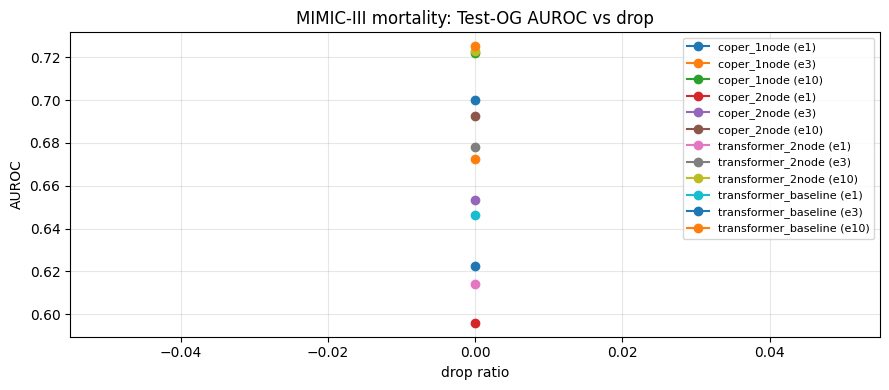

In [6]:
# ---- Plot Test-OG AUROC by drop ----
if 'niters' not in ok.columns:
    plot_df = ok.groupby(['arch_id', 'drop'], as_index=False)['test_og_auroc'].mean()
    fig, ax = plt.subplots(figsize=(8, 4))
    for arch_id in plot_df['arch_id'].unique():
        chunk = plot_df[plot_df['arch_id'] == arch_id].sort_values('drop')
        ax.plot(chunk['drop'], chunk['test_og_auroc'], marker='o', label=arch_id)
else:
    plot_df = ok.groupby(['arch_id', 'niters', 'drop'], as_index=False)['test_og_auroc'].mean()
    fig, ax = plt.subplots(figsize=(9, 4))
    for (arch_id, niters), g in plot_df.groupby(['arch_id', 'niters']):
        chunk = g.sort_values('drop')
        ax.plot(
            chunk['drop'],
            chunk['test_og_auroc'],
            marker='o',
            label=f'{arch_id} (e{int(niters)})',
        )

ax.set_title('MIMIC-III mortality: Test-OG AUROC vs drop')
ax.set_xlabel('drop ratio')
ax.set_ylabel('AUROC')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [7]:
# ---- Export checkpoints to portable bundles (.pt + .json) ----
EXPORT_SCRIPT = BENCH / 'utils' / 'export_coper_checkpoint.py'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
assert EXPORT_SCRIPT.is_file(), f'Missing export script: {EXPORT_SCRIPT}'

ok_for_export = results_df[(results_df['return_code'] == 0) & (results_df['ckpt_exists'])].copy()
if ok_for_export.empty:
    raise RuntimeError('No successful runs with checkpoint files found for export.')

export_rows = []
for _, row in ok_for_export.iterrows():
    arch_id = row['arch_id']
    repo_dir = Path(row['repo_dir'])
    ckpt_path = Path(row['ckpt_path'])
    seed = int(row['seed'])
    drop = float(row['drop'])
    second_node = bool(row['second_node'])
    model_type = row.get('model_type', 'COPER')
    niters = int(row['niters'])

    export_name = f'{arch_id}_drop{drop:g}_s{seed}_e{niters}'
    cmd = [
        sys.executable,
        str(EXPORT_SCRIPT),
        '--repo', str(repo_dir),
        '--ckpt', str(ckpt_path),
        '--out-dir', str(MODELS_DIR),
        '--name', export_name,
        '--drop', str(drop),
        '--random-seed', str(seed),
        '--model-type', str(model_type),
    ]
    if second_node:
        cmd.append('--second-node')

    print(f'Exporting {arch_id} (niters={niters}) -> {export_name}')
    proc = subprocess.run(cmd, text=True, capture_output=True, check=False)
    output = (proc.stdout or '') + '\n' + (proc.stderr or '')

    export_rows.append({
        'arch_id': arch_id,
        'architecture': row['architecture'],
        'model_type': model_type,
        'niters': niters,
        'second_node': second_node,
        'seed': seed,
        'drop': drop,
        'ckpt_path': str(ckpt_path),
        'bundle_name': export_name,
        'return_code': proc.returncode,
        'raw_tail': '\n'.join(output.splitlines()[-80:]),
    })

exports_df = pd.DataFrame(export_rows)
failed_exports = exports_df[exports_df['return_code'] != 0]
if not failed_exports.empty:
    display(exports_df)
    raise RuntimeError('Some checkpoint exports failed. Inspect `exports_df["raw_tail"]`.')

# Persist the latest exported models directory for downstream notebooks (e.g., coper_to_states.ipynb).
latest_models_marker = BENCH / 'results' / 'latest_mimic_compare_models_dir.txt'
latest_models_marker.parent.mkdir(parents=True, exist_ok=True)
latest_models_marker.write_text(str(MODELS_DIR.resolve()) + '\n', encoding='utf-8')
print('Updated latest models marker:', latest_models_marker)
print('Latest models dir:', MODELS_DIR.resolve())

exports_df

Exporting coper_1node (niters=1) -> coper_1node_drop0_s1_e1
Exporting coper_2node (niters=1) -> coper_2node_drop0_s1_e1
Exporting transformer_baseline (niters=1) -> transformer_baseline_drop0_s1_e1
Exporting transformer_2node (niters=1) -> transformer_2node_drop0_s1_e1
Exporting coper_1node (niters=3) -> coper_1node_drop0_s1_e3
Exporting coper_2node (niters=3) -> coper_2node_drop0_s1_e3
Exporting transformer_baseline (niters=3) -> transformer_baseline_drop0_s1_e3
Exporting transformer_2node (niters=3) -> transformer_2node_drop0_s1_e3
Exporting coper_1node (niters=10) -> coper_1node_drop0_s1_e10
Exporting coper_2node (niters=10) -> coper_2node_drop0_s1_e10
Exporting transformer_baseline (niters=10) -> transformer_baseline_drop0_s1_e10
Exporting transformer_2node (niters=10) -> transformer_2node_drop0_s1_e10
Updated latest models marker: /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/results/latest_mimic_compare_models_dir.txt
Latest models dir: /home/charlesv/Desktop/StatisitcalG

,arch_id,architecture,model_type,niters,second_node,seed,drop,ckpt_path,bundle_name,return_code,raw_tail
0,coper_1node,1-NODE (ODE → Perceiver),COPER,1,False,1,0.0,/home/charlesv/Desktop/StatisitcalGenetics/cod...,coper_1node_drop0_s1_e1,0,Saved: /home/charlesv/Desktop/StatisitcalGenet...
1,coper_2node,2-NODE (ODE → Perceiver → ODE on latents),COPER,1,True,1,0.0,/home/charlesv/Desktop/StatisitcalGenetics/cod...,coper_2node_drop0_s1_e1,0,Saved: /home/charlesv/Desktop/StatisitcalGenet...
2,transformer_baseline,TRANSFORMER (ODE → T×T self-attention),TRANSFORMER,1,False,1,0.0,/home/charlesv/Desktop/StatisitcalGenetics/cod...,transformer_baseline_drop0_s1_e1,0,Saved: /home/charlesv/Desktop/StatisitcalGenet...
3,transformer_2node,TRANSFORMER 2-NODE (ODE → T×T self-attention →...,TRANSFORMER,1,True,1,0.0,/home/charlesv/Desktop/StatisitcalGenetics/cod...,transformer_2node_drop0_s1_e1,0,Saved: /home/charlesv/Desktop/StatisitcalGenet...
4,coper_1node,1-NODE (ODE → Perceiver),COPER,3,False,1,0.0,/home/charlesv/Desktop/StatisitcalGenetics/cod...,coper_1node_drop0_s1_e3,0,Saved: /home/charlesv/Desktop/StatisitcalGenet...
5,coper_2node,2-NODE (ODE → Perceiver → ODE on latents),COPER,3,True,1,0.0,/home/charlesv/Desktop/StatisitcalGenetics/cod...,coper_2node_drop0_s1_e3,0,Saved: /home/charlesv/Desktop/StatisitcalGenet...
6,transformer_baseline,TRANSFORMER (ODE → T×T self-attention),TRANSFORMER,3,False,1,0.0,/home/charlesv/Desktop/StatisitcalGenetics/cod...,transformer_baseline_drop0_s1_e3,0,Saved: /home/charlesv/Desktop/StatisitcalGenet...
7,transformer_2node,TRANSFORMER 2-NODE (ODE → T×T self-attention →...,TRANSFORMER,3,True,1,0.0,/home/charlesv/Desktop/StatisitcalGenetics/cod...,transformer_2node_drop0_s1_e3,0,Saved: /home/charlesv/Desktop/StatisitcalGenet...
8,coper_1node,1-NODE (ODE → Perceiver),COPER,10,False,1,0.0,/home/charlesv/Desktop/StatisitcalGenetics/cod...,coper_1node_drop0_s1_e10,0,Saved: /home/charlesv/Desktop/StatisitcalGenet...
9,coper_2node,2-NODE (ODE → Perceiver → ODE on latents),COPER,10,True,1,0.0,/home/charlesv/Desktop/StatisitcalGenetics/cod...,coper_2node_drop0_s1_e10,0,Saved: /home/charlesv/Desktop/StatisitcalGenet...


In [8]:
# ---- Save results to disk ----
import json

tables_dir = notebook_demo_dir("tables", "coper_vs_transformer_mortality", BENCH)
results_csv = tables_dir / 'mimic3_repo_comparison_raw.csv'
summary_csv = tables_dir / 'mimic3_repo_comparison_summary.csv'
exports_csv = tables_dir / 'mimic3_repo_export_summary.csv'
baselines_csv = tables_dir / 'mimic3_baselines_metrics.csv'
baselines_manifest_tables = tables_dir / 'mimic3_baselines_manifest.json'

results_df.to_csv(results_csv, index=False)
summary.to_csv(summary_csv)
if 'exports_df' in globals():
    exports_df.to_csv(exports_csv, index=False)
if 'baselines_df' in globals():
    baselines_df.to_csv(baselines_csv, index=False)
if 'baselines_manifest' in globals():
    baselines_manifest_tables.write_text(json.dumps(baselines_manifest, indent=2), encoding='utf-8')

print('Saved:', results_csv)
print('Saved:', summary_csv)
if exports_csv.exists():
    print('Saved:', exports_csv)
if baselines_csv.exists():
    print('Saved:', baselines_csv)
if baselines_manifest_tables.exists():
    print('Saved:', baselines_manifest_tables)

Saved: /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/results/demo_outputs/coper_vs_transformer_mortality/tables/mimic3_repo_comparison_raw.csv
Saved: /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/results/demo_outputs/coper_vs_transformer_mortality/tables/mimic3_repo_comparison_summary.csv
Saved: /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/results/demo_outputs/coper_vs_transformer_mortality/tables/mimic3_repo_export_summary.csv
Saved: /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/results/demo_outputs/coper_vs_transformer_mortality/tables/mimic3_baselines_metrics.csv
Saved: /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/results/demo_outputs/coper_vs_transformer_mortality/tables/mimic3_baselines_manifest.json
